In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


In [1]:
import requests
import pandas as pd


em_fields = {
    'f2':'最新价',
    'f3':'涨跌幅',
    'f6':'成交额',
    'f7':'振幅',
    'f8':'换手率',
    'f12':'证券代码',
    'f14':'证券名称',
    'f20':'总市值',
    'f21':'流通市值',
    'f26':'上市日期',
    'f100':'行业板块',
}
fields = [ i for i in em_fields]
fields = ','.join(fields)


def fetch_spot_em(market):
    
    if market == 'China':
        pz = '6000'
        fs = 'm:0 t:6,m:0 t:13,m:0 t:80,m:1 t:2,m:1 t:23,m:0 t:81 s:2048'
    elif market == 'HK':
        pz = '5000'
        fs = 'm:128 t:3,m:128 t:4,m:128 t:1,m:128 t:2'
    elif market == 'US':
        pz = '15000'
        fs = 'm:105,m:106,m:107'       
    elif market == 'UK':
        pz = '10000'
        fs = 'm:155 t:1,m:155 t:2,m:155 t:3,m:156 t:1,m:156 t:2,m:156 t:5,m:156 t:6,m:156 t:7,m:156 t:8'       
    else:
        raise('Market not support')
    
    url = 'http://40.push2.eastmoney.com/api/qt/clist/get'
    params = {
        'pn': '1',
        'pz': pz,
        'po': '1',
        'np': '1',
        'ut': 'bd1d9ddb04089700cf9c27f6f7426281',
        'fltt': '2',
        'invt': '2',
        'fid': 'f3',
        'fs': fs,
        'fields': fields,
        '_': '1631107510188',
    }

    r = requests.get(url, params=params, timeout=10)
    data_json = r.json()
    temp_df = pd.DataFrame(data_json['data']['diff'])
    temp_df = temp_df.rename(columns = em_fields)

    temp_df['流通市值'] = (pd.to_numeric(temp_df['流通市值'], errors="coerce")/100000000).round(2).fillna(0) 
    temp_df['总市值'] = (pd.to_numeric(temp_df['总市值'], errors="coerce")/100000000).round(2).fillna(0) 
    temp_df['成交额'] = (pd.to_numeric(temp_df['成交额'], errors="coerce")/100000000).round(2).fillna(0) 
    temp_df['最新价'] = pd.to_numeric(temp_df['最新价'], errors="coerce")
    temp_df['涨跌幅'] = pd.to_numeric(temp_df['涨跌幅'], errors="coerce")
    temp_df['振幅'] = pd.to_numeric(temp_df['振幅'], errors="coerce")
    temp_df['换手率'] = pd.to_numeric(temp_df['换手率'], errors="coerce")
    temp_df = temp_df[['证券代码','证券名称','流通市值','总市值','最新价', '涨跌幅','振幅','成交额','换手率','上市日期','行业板块']]
    
    temp_df = temp_df[temp_df['流通市值'] > 0]
    temp_df = temp_df[temp_df['总市值'] > 0]
    temp_df = temp_df[temp_df['成交额'] > 0]
    return temp_df


In [6]:
import requests
import pandas as pd
import demjson


def stock_zh_index_daily_em(
    symbol: str = "csi931151",
    start_date: str = "19900101",
    end_date: str = "20500101",
) -> pd.DataFrame:
    """
    东方财富网-股票指数数据
    https://quote.eastmoney.com/center/hszs.html
    :param symbol: 带市场标识的指数代码; sz: 深交所, sh: 上交所, csi: 中信指数 + id(000905)
    :type symbol: str
    :param start_date: 开始时间
    :type start_date: str
    :param end_date: 结束时间
    :type end_date: str
    :return: 指数数据
    :rtype: pandas.DataFrame
    """
    market_map = {"sz": "0", "sh": "1", "csi": "2"}
    url = "http://push2his.eastmoney.com/api/qt/stock/kline/get"
    if symbol.find("sz") != -1:
        secid = "{}.{}".format(market_map["sz"], symbol.replace("sz", ""))
    elif symbol.find("sh") != -1:
        secid = "{}.{}".format(market_map["sh"], symbol.replace("sh", ""))
    elif symbol.find("csi") != -1:
        secid = "{}.{}".format(market_map["csi"], symbol.replace("csi", ""))
    else:
        return
    params = {
        "cb": "jQuery1124033485574041163946_1596700547000",
        "secid": secid,
        "ut": "fa5fd1943c7b386f172d6893dbfba10b",
        "fields1": "f1,f2,f3,f4,f5",
        "fields2": "f51,f52,f53,f54,f55,f56,f57,f58",
        "klt": "101",  # 日频率
        "fqt": "0",
        "beg": start_date,
        "end": end_date,
        "_": "1596700547039",
    }
    r = requests.get(url, params=params)
    data_text = r.text
    data_json = demjson.decode(data_text[data_text.find("{") : -2])
    temp_df = pd.DataFrame([item.split(",") for item in data_json["data"]["klines"]])
    temp_df.columns = ["date", "open", "close", "high", "low", "volume", "amount", "_"]
    temp_df = temp_df[["date", "open", "close", "high", "low", "volume", "amount"]]

    temp_df["open"] = pd.to_numeric(temp_df["open"], errors="coerce")
    temp_df["close"] = pd.to_numeric(temp_df["close"], errors="coerce")
    temp_df["high"] = pd.to_numeric(temp_df["high"], errors="coerce")
    temp_df["low"] = pd.to_numeric(temp_df["low"], errors="coerce")
    temp_df["volume"] = pd.to_numeric(temp_df["volume"], errors="coerce")
    temp_df["amount"] = pd.to_numeric(temp_df["amount"], errors="coerce")
    return temp_df

In [2]:
from pybroker.ext.data import AKShare
import pandas_ta as ta
import pandas as pd 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from scipy.stats import linregress
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime


def fetch_stock_k_line(symbol):
    ipo_date = stock_list[stock_list['证券代码']==symbol]['上市日期'].values[0]
    today = datetime.today().strftime("%Y%m%d")
    
    akshare = AKShare()
    # You can substitute 000001.SZ with 000001, and it will still work!
    # and you can set start_date as "20210301" format
    # You can also set adjust to 'qfq' or 'hfq' to adjust the data,
    # and set timeframe to '1d', '1w' to get daily, weekly data
    df = akshare.query(
        symbols=[symbol],
        start_date= str(ipo_date),
        end_date= today,
        adjust="qfq",
        timeframe="1d",
    )
    
    df['sma_30'] = df.ta.sma(close = df["close"], length=30)
    df['sma_60'] = df.ta.sma(close = df["close"], length=60)
    df['sma_100'] = df.ta.sma(close = df["close"], length=100)
    df['sma_200'] = df.ta.sma(close = df["close"], length=200)
    df = df.set_index('date')
    df = df.asfreq('B')
    df = df.dropna()
    return df

def find_peaks(df, period = 100):
    ilocs_min = argrelextrema(df['low'].values, np.less_equal, order=period)[0]
    ilocs_max = argrelextrema(df['high'].values, np.greater_equal, order=period)[0]
    #上市60天以内的peak不算

    df_len = len(df)
    df['number'] = np.arange(df_len)+1
    df_high = df.iloc[ilocs_max].copy().drop_duplicates(subset=['high'],keep='last')
    # df_high = df_high[df_high.index>30] 
    df_low = df.iloc[ilocs_min].copy().drop_duplicates(subset=['low'],keep='last')
    # df_low = df_low#[1:-1]
    return df_high, df_low


    # 斜率要在合理范围内
def df_highTrend(df, df_high):
    df_high_trend = df_high
    while len(df_high_trend)>2:
        slope, intercept, r_value, p_value, std_err = linregress(x=df_high_trend['number'], y=df_high_trend['high'])
        df_high_trend = df_high_trend.loc[df_high_trend['high'] > slope * df_high_trend['number'] + intercept]
    if len(df_high_trend)<2:
        print('<2')
        highest = df_high[df_high.index != df_high.index.values[0]].nlargest(1, ['high'], keep='first') 
        df_high_trend = pd.concat([df_high_trend, highest])  
    slope, intercept, r_value, p_value, std_err = linregress(x=df_high_trend['number'], y=df_high_trend['high'])
    df['Uptrend'] = slope * df['number'] + intercept
#     df_high = df.iloc[ilocs_max][1:].nlargest(2, ['high'], keep='first')       

def df_lowTrend(df,df_low):
    df_low_trend = df_low.nsmallest(5, ['low'], keep='first') 
    while len(df_low_trend)>2:
        slope, intercept, r_value, p_value, std_err = linregress(x=df_low_trend['number'], y=df_low_trend['low'])
        df_low_trend = df_low_trend.loc[df_low_trend['low'] < slope * df_low_trend['number'] + intercept] 
    if len(df_low_trend)<2:
        # print('low<2',df_low_trend.index.values[0])
        lowest = df_low[df_low.index != df_low.index.values[0]].nsmallest(1, ['low'], keep='first') 
        df_low_trend = pd.concat([df_low_trend, lowest])  
    #     slope, intercept, r_value, p_value, std_err = linregress(x=df_low['Number'], y=df_low['low'])
    #     if slope < 0:
    #         df_low = df.iloc[ilocs_min][1:].nsmallest(3, ['low'], keep='first')   
    print(df_low_trend)
    slope, intercept, r_value, p_value, std_err = linregress(x=df_low_trend['number'], y=df_low_trend['low'])
    df['Downtrend'] = slope * df['number'] + intercept



import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
pd.options.plotting.backend = "matplotlib"
def plot_figure(df,df_high,df_low):
    df['close'].plot(figsize=(25,10), lw=1, alpha=.3)
    # filter prices that are peaks and plot them differently to be visable on the plot
    # df['sma_30'].plot(lw=1,color='darkorange', alpha=.5)
    # df['sma_60'].plot(lw=1,color='blue', alpha=.5)
    # df['sma_100'].plot(lw=1,color='magenta', alpha=.5)
    # df['sma_200'].plot(lw=1.5,color='red')
    df_high['high'].plot(style='.', lw=10, color='red', marker=7)       
    df_low['low'].plot(style='.', lw=10, color='green', marker=6)
    # df['Downtrend'].plot(lw=1,color='grey')
    # df['Uptrend'].plot(lw=1,color='grey')


Loading bar data...
Loaded bar data: 0:00:01 



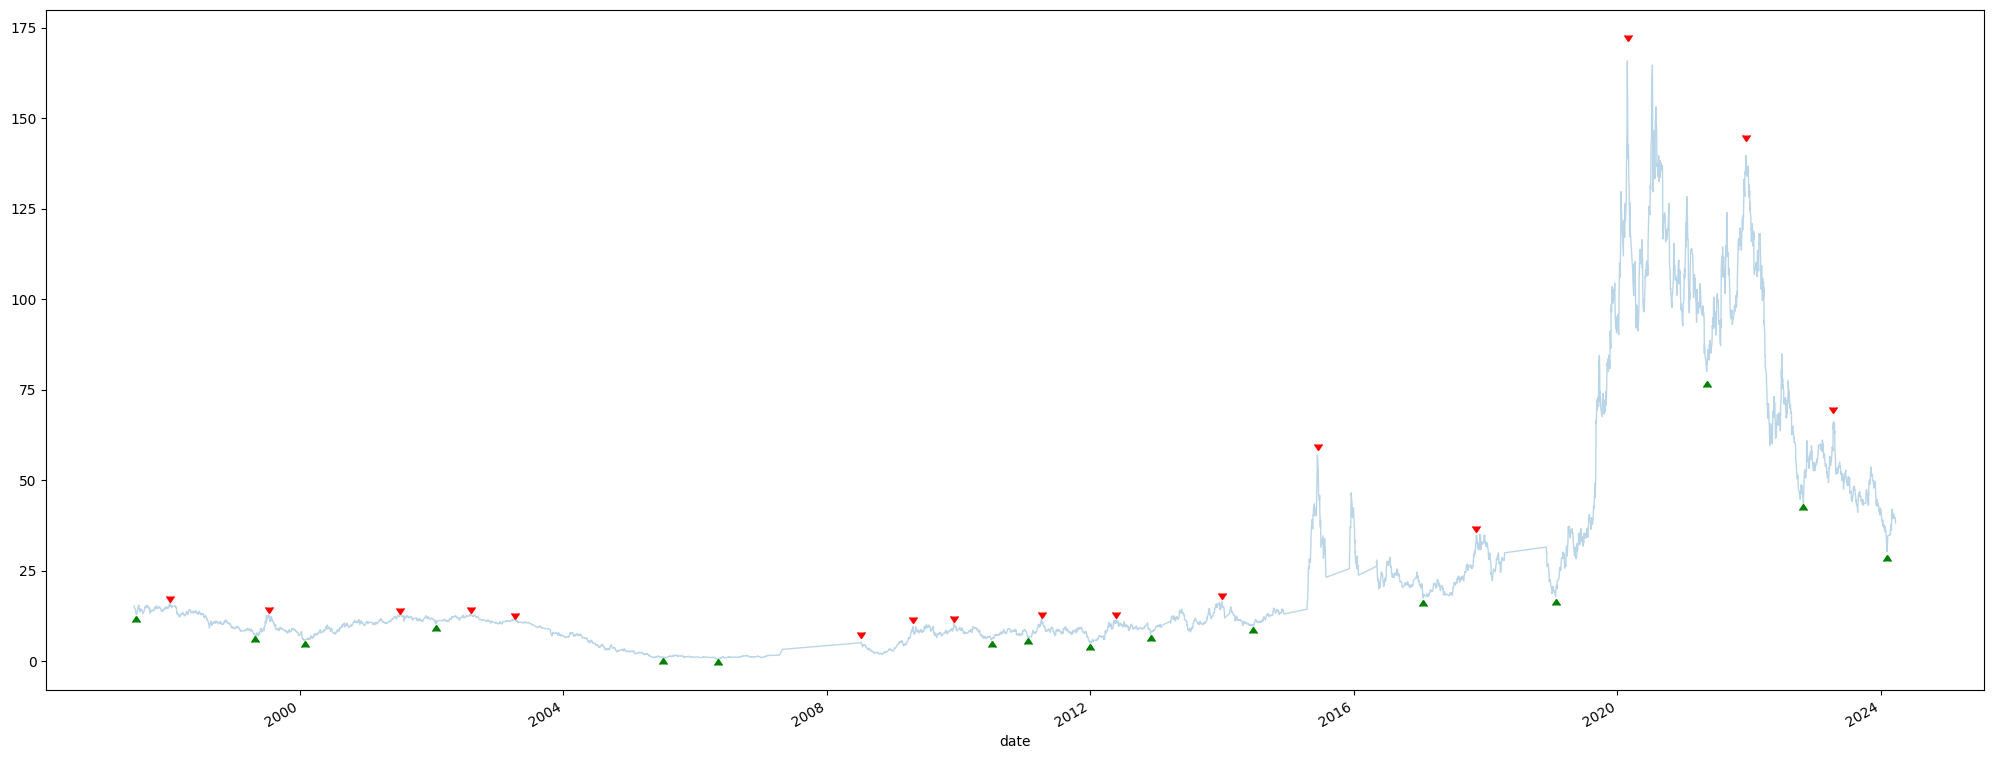

In [3]:
symbol = '600745'
stock_list = fetch_spot_em(market='China')
df = fetch_stock_k_line(symbol)
df_high, df_low = find_peaks(df, period = 120)
# df_highTrend(df, df_high)
# df_lowTrend(df,df_low)
plot_figure(df,df_high,df_low)

Loading bar data...
Loaded bar data: 0:00:00 



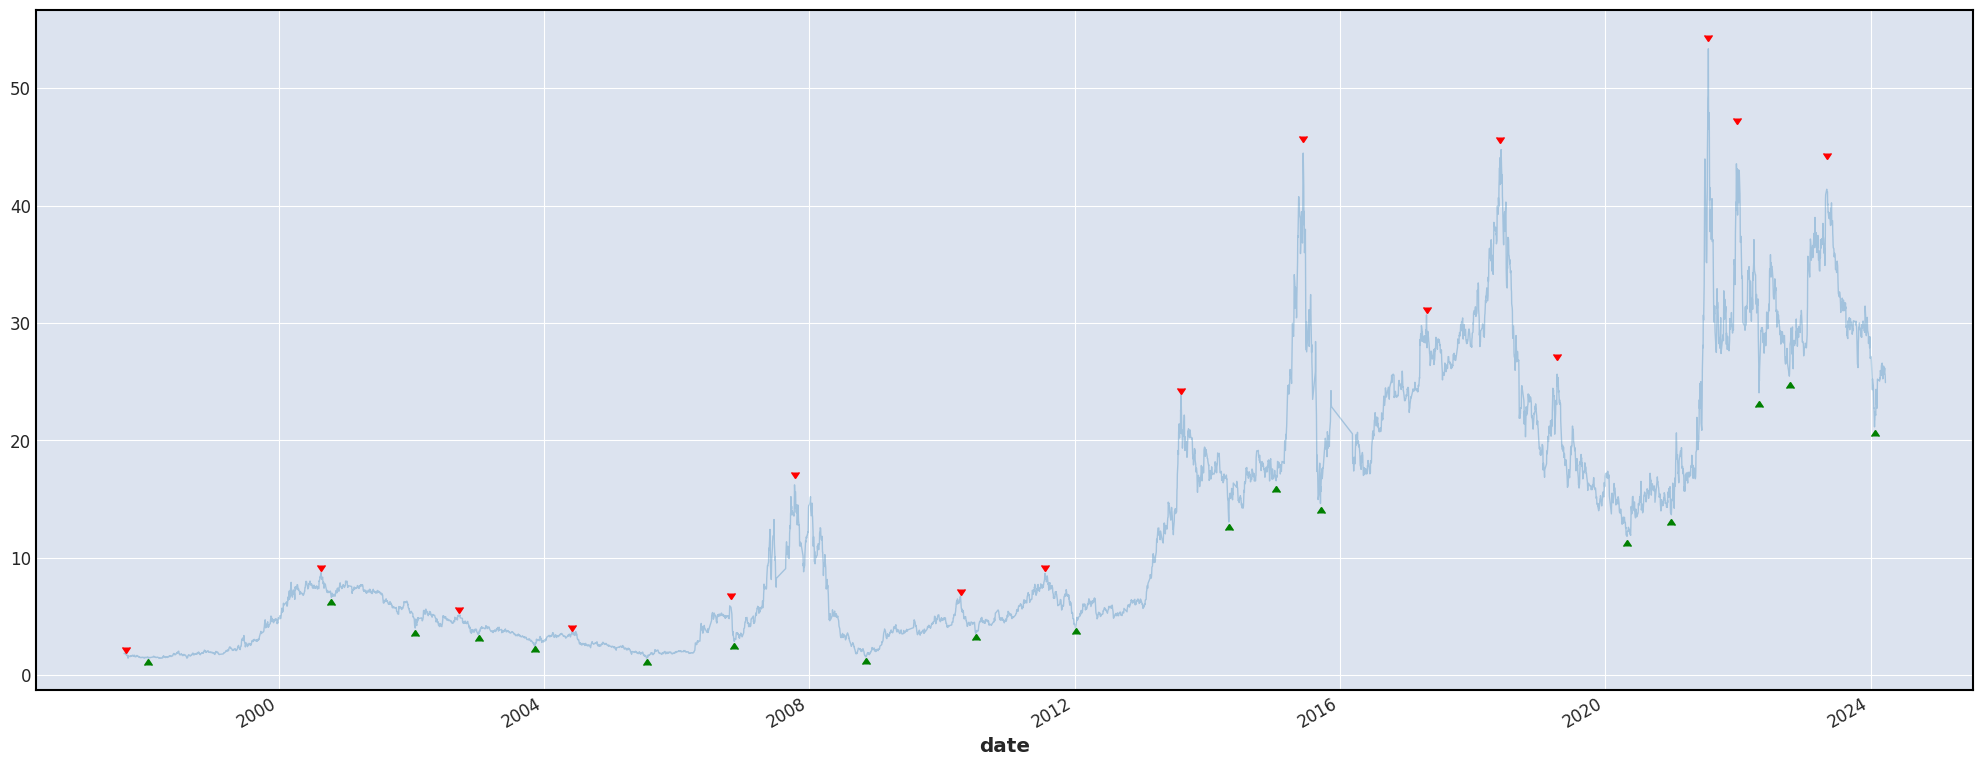

In [177]:
symbol = '600771'
stock_list = fetch_spot_em(market='China')
df = fetch_stock_k_line(symbol)
df_high, df_low = find_peaks(df, period = 100)
# df_highTrend(df, df_high)
# df_lowTrend(df,df_low)
plot_figure(df,df_high,df_low)

In [150]:
stock_list['上市日期'] = pd.to_datetime(stock_list['上市日期'], format='%Y%m%d')
stock_list['上市年份'] = stock_list['上市日期'].apply(lambda x: x.year)
stock_list[stock_list['上市年份'] < 2000].sort_values(by= ['总市值','行业板块'], ascending = False)

,证券代码,证券名称,流通市值,总市值,最新价,涨跌幅,振幅,成交额,换手率,上市日期,行业板块,上市年份
3232,000858,五 粮 液,5955.43,5955.55,153.43,-2.03,2.81,30.98,0.52,1998-04-27,酿酒行业,1998
1914,600809,山西汾酒,3011.48,3011.48,246.85,-1.15,2.76,8.08,0.27,1994-01-06,酿酒行业,1994
5094,000568,泸州老窖,2687.15,2695.80,183.14,-3.76,4.30,17.58,0.65,1994-05-09,酿酒行业,1994
840,600690,海尔智家,1473.05,2203.80,23.35,0.26,1.33,5.60,0.38,1993-11-19,家电行业,1993
726,000651,格力电器,2129.46,2147.82,38.14,0.58,1.27,11.23,0.53,1996-11-18,家电行业,1996
1610,600000,浦发银行,2066.39,2066.39,7.04,-0.85,2.25,2.53,0.12,1999-11-10,银行,1999
1818,000001,平安银行,2010.41,2010.45,10.36,-1.05,1.34,10.66,0.53,1991-04-03,银行,1991
1628,600887,伊利股份,1806.41,1823.89,28.65,-0.87,2.21,9.27,0.52,1996-03-12,食品饮料,1996
674,600188,兖矿能源,1087.77,1786.94,24.02,0.71,1.51,8.25,0.76,1998-07-01,煤炭行业,1998
3915,000625,长安汽车,1462.91,1766.27,17.81,-2.46,3.34,43.14,2.93,1997-06-10,汽车整车,1997


In [12]:
round((df[-1:]['Downtrend']-df[-1:]['close'])/df[-1:]['close'],2).values[0]

-1.03

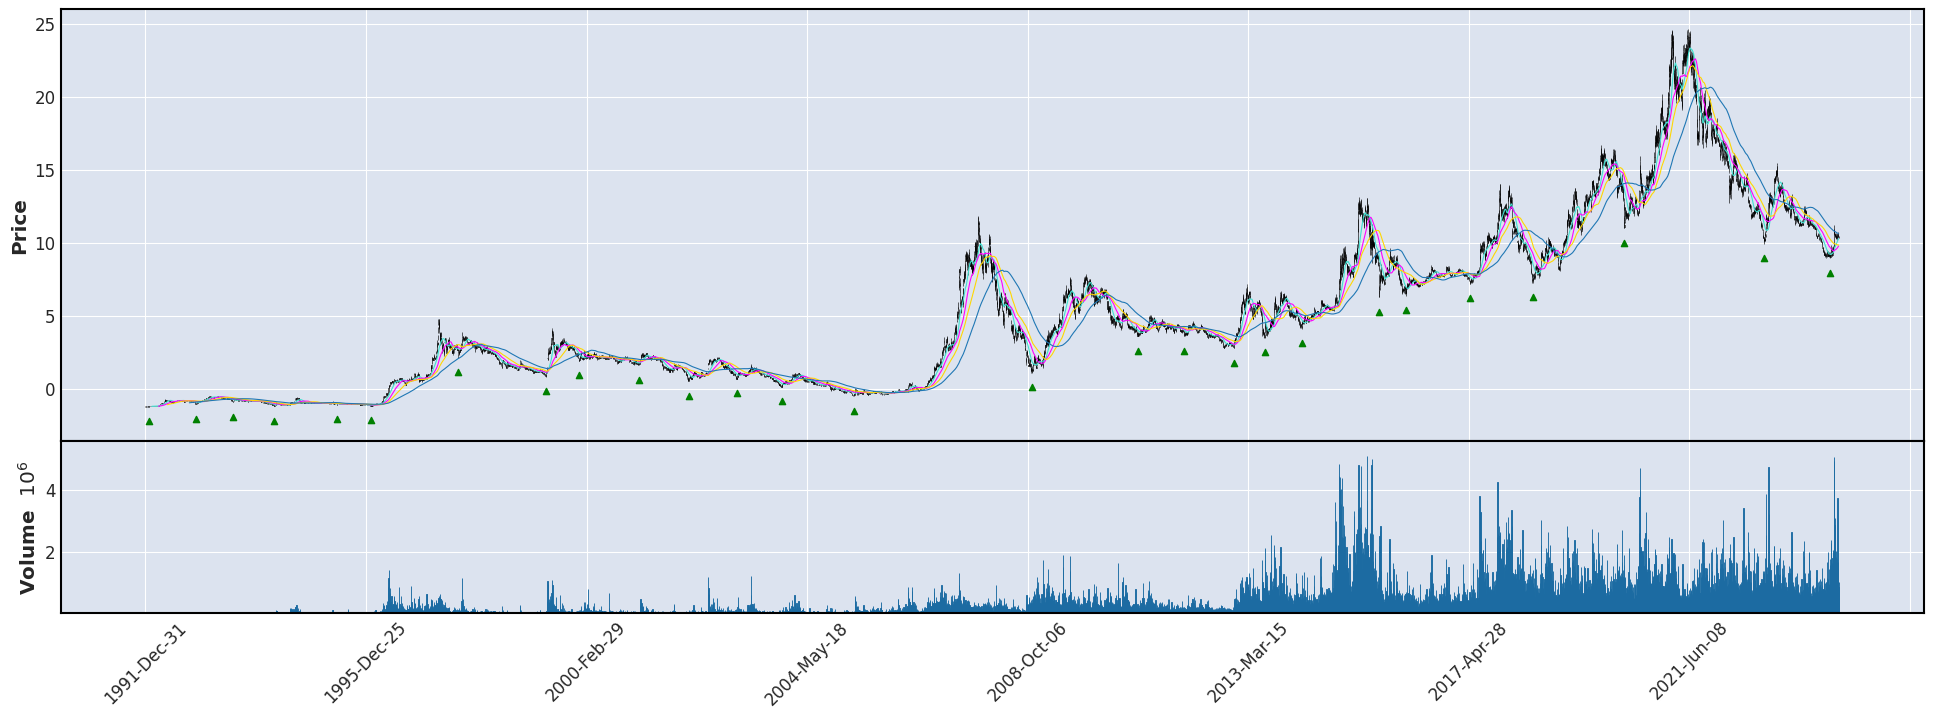

In [37]:
import mplfinance as mpf


dfl = df.merge(df_low, how='left', left_on = df.index, right_on = df_low.index)
apdict = mpf.make_addplot(dfl['low_y'] - 1 ,type='scatter',markersize=20,marker='^',color = 'g')
mpf.plot(df, type='candle',mav=(30,60,100,200), volume=True,addplot=apdict, figratio=(30,10), figscale=1.5)
# df_low['low'].plot(style='.', lw=10, color='green', marker=6)



In [13]:
round((df[-1:]['Uptrend']-df[-1:]['close'])/df[-1:]['close'],2).values[0]

0.58

In [17]:
df[-1:]

,symbol,open,high,low,close,volume,sma_30,sma_60,sma_100,sma_200,number,Uptrend,Downtrend
date,,,,,,,,,,,,,
2024-03-22,600089,15.51,15.65,15.33,15.58,436910,15.292,14.655,14.3103,14.93555,6301,24.605257,-0.452935


In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['open'],
                high=df['high'],
                low=df['low'],
                close=df['close'],
                increasing_line_color= 'red', decreasing_line_color= 'green'),
                go.Scatter(x=df.index, y=df['sma_30'], line=dict(color='yellow', width=0.5)),
                go.Scatter(x=df.index, y=df['sma_60'], line=dict(color='blue', width=0.5)),
                go.Scatter(x=df.index, y=df['sma_100'], line=dict(color='grey', width=0.5)),
                go.Scatter(x=df.index, y=df['sma_200'], line=dict(color='red', width=2)),
                go.Marker(x=df_high.number, y=df_high.high + 1, marker_symbol= "triangle-down", mode="markers", marker=dict(color='red')),
                go.Marker(x=df_low.number, y=df_low.low - 1, marker_symbol= "triangle-up", mode="markers", marker=dict(color='green')),
                go.Scatter(x=df.number, y=df.Downtrend, line=dict(color='grey', width=1))
                     ])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.update_xaxes(
    rangebreaks=[
        dict(bounds=["sat", "mon"]), #hide weekends
        dict(values=["2015-12-25", "2016-01-01"])  # hide Christmas and New Year's
    ]
)
fig.show()

In [92]:
sh001 = stock_zh_index_daily_em(symbol = "sh000001")

In [98]:
# shzs_1 = sh001[sh001['date'] <= '1996-12-25']

shzs_1 = sh001[sh001['date'].between('1996-01-19','1996-12-25')]
shzs_2 = sh001[sh001['date'].between('1996-01-19','2005-06-06')]
brk_1  = sh001[sh001['date'].between('2005-06-06','2005-12-06')]
shzs_3 = sh001[sh001['date'].between('2005-12-06','2013-06-24')]
brk_2  = sh001[sh001['date'].between('2013-06-24','2014-07-10')]
shzs_4 = sh001[sh001['date'].between('2014-07-10','2018-10-19')]
brk_3  = sh001[sh001['date'].between('2018-10-19','2019-01-04')]
shzs_5 = sh001[sh001['date'].between('2019-01-04','2024-12-12')]

# shzs_1 = shzs_1.set_index('date')
# shzs_2 = shzs_2.set_index('date')
# shzs_3 = shzs_3.set_index('date')
# shzs_4 = shzs_4.set_index('date')
# shzs_5 = shzs_5.set_index('date')

<Axes: >

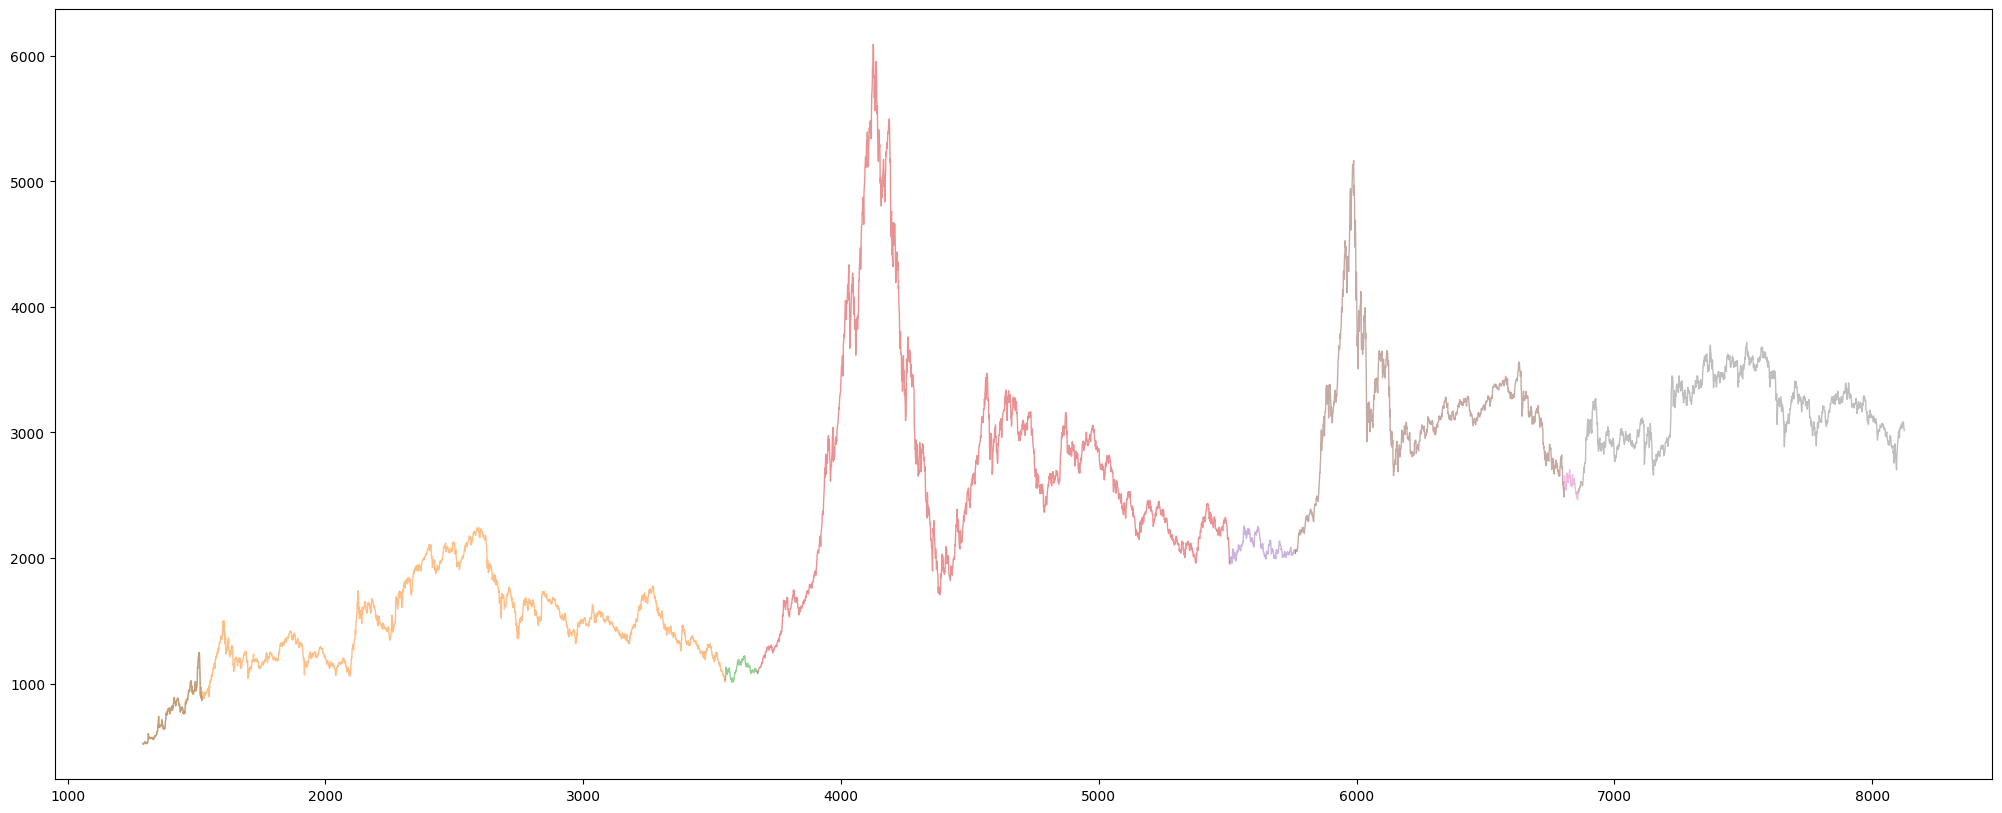

In [105]:
shzs_1['close'].plot(figsize=(25,10), lw=1, alpha=.5)
shzs_2['close'].plot(figsize=(25,10), lw=1, alpha=.5)
brk_1['close'].plot(figsize=(25,10), lw=1, alpha=.5)
shzs_3['close'].plot(figsize=(25,10), lw=1, alpha=.5)
brk_2['close'].plot(figsize=(25,10), lw=1, alpha=.5)
shzs_4['close'].plot(figsize=(25,10), lw=1, alpha=.5)
brk_3['close'].plot(figsize=(25,10), lw=1, alpha=.5)
shzs_5['close'].plot(figsize=(25,10), lw=1, alpha=.5)


In [75]:
shzs_1['close'] = shzs_1['close'] / shzs_1['close'].head(1).values[0]
shzs_2['close'] = shzs_2['close'] / shzs_2['close'].head(1).values[0]
shzs_3['close'] = shzs_3['close'] / shzs_3['close'].head(1).values[0]
shzs_4['close'] = shzs_4['close'] / shzs_4['close'].head(1).values[0]
shzs_5['close'] = shzs_5['close'] / shzs_5['close'].head(1).values[0]

In [76]:
shzs_2 = shzs_2.reset_index(inplace = False)
shzs_3 = shzs_3.reset_index(inplace = False)
shzs_4 = shzs_4.reset_index(inplace = False)
shzs_5 = shzs_5.reset_index(inplace = False)

<Axes: >

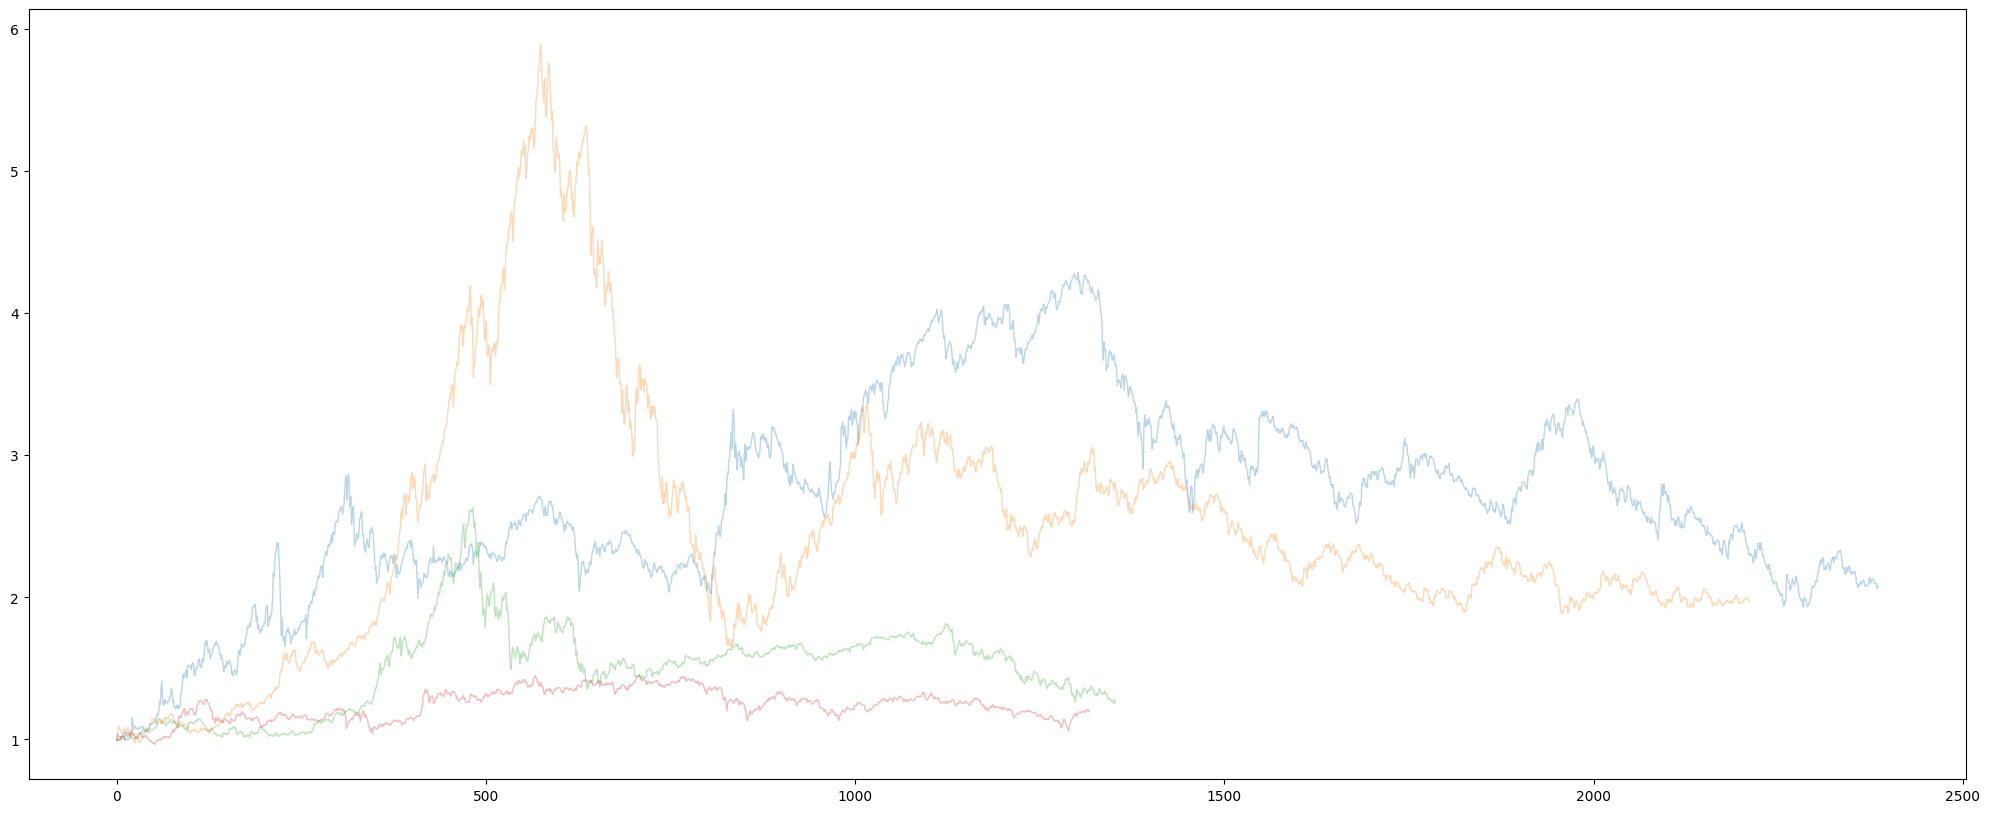

In [77]:
# shzs_1['close'].plot(figsize=(25,10), lw=1, alpha=.3)
shzs_2['close'].plot(figsize=(25,10), lw=1, alpha=.3)
shzs_3['close'].plot(figsize=(25,10), lw=1, alpha=.3)
shzs_4['close'].plot(figsize=(25,10), lw=1, alpha=.3)
shzs_5['close'].plot(figsize=(25,10), lw=1, alpha=.3)

In [60]:
import pywencai

query = '2023/08/25 到 2024/02/06 区间涨幅 非st 非北交所 市值50亿以上'
loop = True
query_type = 'stock'

'''
stock	股票
zhishu	指数
fund	基金
hkstock	港股
usstock	美股
threeboard	新三板
conbond	可转债
insurance	保险
futures	期货
lccp	理财
foreign_exchange	外汇
'''

r = pywencai.get(query=query,loop = loop, log = True, query_type = query_type)

[pywencai] 2024-03-25 10:26:09,983 - INFO - 获取condition开始
INFO:pywencai.wencai:获取condition开始
[pywencai] 2024-03-25 10:26:12,153 - INFO - 获取get_robot_data成功
INFO:pywencai.wencai:获取get_robot_data成功
[pywencai] 2024-03-25 10:26:12,156 - INFO - 第1页开始
INFO:pywencai.wencai:第1页开始
[pywencai] 2024-03-25 10:26:13,464 - INFO - 第1页成功
INFO:pywencai.wencai:第1页成功
[pywencai] 2024-03-25 10:26:13,509 - INFO - 第2页开始
INFO:pywencai.wencai:第2页开始
[pywencai] 2024-03-25 10:26:14,960 - INFO - 第2页成功
INFO:pywencai.wencai:第2页成功
[pywencai] 2024-03-25 10:26:14,997 - INFO - 第3页开始
INFO:pywencai.wencai:第3页开始
[pywencai] 2024-03-25 10:26:16,314 - INFO - 第3页成功
INFO:pywencai.wencai:第3页成功
[pywencai] 2024-03-25 10:26:16,330 - INFO - 第4页开始
INFO:pywencai.wencai:第4页开始
[pywencai] 2024-03-25 10:26:17,592 - INFO - 第4页成功
INFO:pywencai.wencai:第4页成功
[pywencai] 2024-03-25 10:26:17,608 - INFO - 第5页开始
INFO:pywencai.wencai:第5页开始
[pywencai] 2024-03-25 10:26:19,569 - INFO - 第5页成功
INFO:pywencai.wencai:第5页成功
[pywencai] 2024-03-25 10:26:19,579

In [62]:
r.to_csv('test.csv')